# Minimales Loadflow-Notebook

Dieses Notebook zeigt ein kompaktes End-to-End-Beispiel:
- minimale `LoadFlowProblem`-Definition,
- `LoadFlowBatch` und `LoadFlowDataLoader`,
- 3-Bus-Beispiel mit Visualisierung,
- Tiny Ready-to-Use Modell + Trainingssetup.

## 1) Abhängigkeiten und Imports

Wir importieren nur die benötigten Bausteine und machen einen kleinen Environment-Check.

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from collections.abc import Iterator
from pathlib import Path
from typing import Any
import importlib

import numpy as np
import jax
import jax.numpy as jnp

from energnn.graph import EdgeStructure, GraphShape, GraphStructure, collate_graphs, max_shape
from energnn.graph.edge import Edge
from energnn.graph.graph import Graph
from energnn.graph.jax import JaxEdge, JaxGraph
from energnn.model.ready_to_use import TinyRecurrentEquivariantGNN
from energnn.problem import Problem, ProblemBatch, ProblemLoader
from energnn.trainer import SimpleTrainer

import utils.visualization_utils as visualization_utils


def _maybe_version(mod_name: str) -> str:
    try:
        mod = __import__(mod_name)
        return getattr(mod, "__version__", "installed")
    except Exception:
        return "not installed"


env_info = {
    "python": f"{__import__('sys').version_info.major}.{__import__('sys').version_info.minor}",
    "jax": _maybe_version("jax"),
    "numpy": _maybe_version("numpy"),
    "pandapower": _maybe_version("pandapower"),
}
env_info

{'python': '3.11', 'jax': '0.9.0', 'numpy': '2.3.4', 'pandapower': '3.4.0'}

## 2) Minimale Problemstruktur (`LoadFlowProblem`) definieren

Diese Klasse enthält die Kern-APIs: `loss`, `get_context`, `get_gradient`, `get_metrics`.

In [3]:
class MinimalLoadFlowProblem(Problem):
    CONTEXT_STRUCTURE = GraphStructure(
        edges={
            "buses": EdgeStructure.from_list(
                address_list=["bus"],
                feature_list=["bus_type", "p_load_pu", "q_load_pu", "p_gen_pu", "vm_set_pu"],
            ),
            "lines": EdgeStructure.from_list(
                address_list=["from_bus", "to_bus"],
                feature_list=["kind", "r_pu", "x_pu", "b_pu", "tap", "rating_pu"],
            ),
        }
    )

    DECISION_STRUCTURE = GraphStructure(
        edges={
            "buses": EdgeStructure.from_list(
                address_list=None,
                feature_list=["vm_pu", "va_deg", "q_gen_pu"],
            )
        }
    )

    def __init__(self, *, context: Graph, oracle: Graph):
        self._context = context
        self._oracle = oracle
        self.jax_context = JaxGraph.from_numpy_graph(context)
        self.jax_oracle = JaxGraph.from_numpy_graph(oracle)
        self._decision_grad_fn = jax.grad(lambda pred: self.loss(prediction=pred), allow_int=True)

    @staticmethod
    def _idx_map(edge: JaxEdge) -> dict[str, int]:
        if edge.feature_names is None:
            return {}
        return {k: int(np.asarray(v).reshape(-1)[0]) for k, v in edge.feature_names.items()}

    @staticmethod
    def _sanitize_cotangent_leaf(cotangent_leaf, primal_leaf):
        primal_arr = np.asarray(primal_leaf)
        if primal_arr.dtype.kind not in ("f", "c"):
            return jnp.zeros_like(primal_leaf)

        try:
            cotangent_arr = jnp.asarray(cotangent_leaf, dtype=primal_leaf.dtype)
        except Exception:
            return jnp.zeros_like(primal_leaf)

        return jnp.nan_to_num(cotangent_arr)

    def _edge_sq_error_and_count(self, prediction_edge: JaxEdge, target_edge: JaxEdge) -> tuple[jax.Array, jax.Array]:
        idx_pred = self._idx_map(prediction_edge)
        idx_tgt = self._idx_map(target_edge)

        sq_error_sum = jnp.array(0.0)
        n_values = jnp.array(0.0)

        for feature_name, i_pred in idx_pred.items():
            if feature_name not in idx_tgt:
                continue
            i_tgt = idx_tgt[feature_name]
            diff = prediction_edge.feature_array[..., i_pred] - target_edge.feature_array[..., i_tgt]
            sq_error_sum += jnp.sum(diff**2)
            n_local = jnp.maximum(jnp.array(diff.size, dtype=diff.dtype), jnp.array(1.0, dtype=diff.dtype))
            n_values += n_local

        return sq_error_sum, n_values

    def loss(self, *, prediction: JaxGraph, target: JaxGraph | None = None) -> jax.Array:
        if target is None:
            target = self.jax_oracle

        sq_error_sum = jnp.array(0.0)
        n_values = jnp.array(0.0)

        for edge_name, pred_edge in prediction.edges.items():
            if edge_name not in target.edges:
                continue
            tgt_edge = target.edges[edge_name]
            edge_sq_error_sum, edge_n_values = self._edge_sq_error_and_count(pred_edge, tgt_edge)
            sq_error_sum += edge_sq_error_sum
            n_values += edge_n_values

        return sq_error_sum / jnp.maximum(n_values, 1.0)

    def get_context(self, get_info: bool = False):
        info: dict[str, Any] = {}
        if get_info:
            info = {
                "context_true_shape": self._context.true_shape.to_jsonable_dict(),
                "oracle_true_shape": self._oracle.true_shape.to_jsonable_dict(),
            }
        return self.jax_context, info

    def get_gradient(self, *, decision: JaxGraph, get_info: bool = False):
        raw_gradient = self._decision_grad_fn(decision)
        gradient = jax.tree.map(self._sanitize_cotangent_leaf, raw_gradient, decision)

        info: dict[str, Any] = {}
        if get_info:
            mse = self.loss(prediction=decision)
            info = {"mse": mse, "rmse": jnp.sqrt(mse)}
        return gradient, info

    def get_metrics(self, *, decision: JaxGraph, get_info: bool = False):
        mse = self.loss(prediction=decision)
        rmse = jnp.sqrt(mse)
        info: dict[str, Any] = {}
        if get_info:
            info = {"mse": mse, "rmse": rmse}
        return np.atleast_1d(np.asarray(rmse, dtype=np.float32)), info

    def get_metadata(self):
        return {
            "name": "minimal-load-flow-problem",
            "context_shape": self._context.true_shape.to_jsonable_dict(),
            "decision_shape": self._oracle.true_shape.to_jsonable_dict(),
        }

    def save(self, *, path: str) -> None:
        raise NotImplementedError("Minimal notebook example: save is not implemented.")

    @property
    def context_structure(self) -> GraphStructure:
        return self.CONTEXT_STRUCTURE

    @property
    def decision_structure(self) -> GraphStructure:
        return self.DECISION_STRUCTURE

print("Context structure:\n", MinimalLoadFlowProblem.CONTEXT_STRUCTURE)
print("-----------------------------------------------------------------------------\n")
print("Decision structure:\n", MinimalLoadFlowProblem.DECISION_STRUCTURE)

Context structure:
                 Addresses                                               Features
Name                                                                            
buses               [bus]  [bus_type, p_load_pu, q_load_pu, p_gen_pu, vm_set_pu]
lines  [from_bus, to_bus]               [kind, r_pu, x_pu, b_pu, tap, rating_pu]
-----------------------------------------------------------------------------

Decision structure:
       Addresses                   Features
Name                                      
buses      None  [vm_pu, va_deg, q_gen_pu]


## 3) 3-Bus-Beispielnetz erzeugen und in Graph-Format überführen

Wir bauen ein kleines synthetisches 3-Bus-Problem (Slack/PQ/PV) direkt als Kontext- und Oracle-Graph.

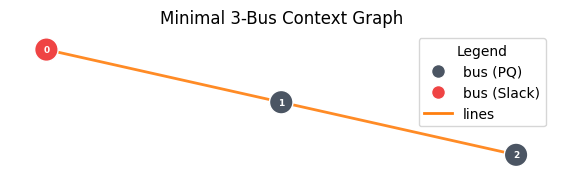

{'context_true_shape': {'edges': {'buses': 3, 'lines': 2}, 'addresses': 3},
 'oracle_true_shape': {'edges': {'buses': 3}, 'addresses': 3},
 'context_info_keys': ['context_true_shape', 'oracle_true_shape'],
 'bus_type_values': [2.0, 0.0, 0.0],
 'visualization': 'shown'}

In [7]:
def make_3bus_problem(seed: int = 0) -> MinimalLoadFlowProblem:
    rng = np.random.default_rng(seed)
    n = 3
    registry = np.arange(n, dtype=np.int32)

    bus_address = np.arange(n, dtype=np.int32)
    line_from = np.array([0, 2], dtype=np.int32)
    line_to = np.array([1, 1], dtype=np.int32)

    bus_features = {
        "bus_type": np.array([2.0, 0.0, 0.0], dtype=np.float32), # 0 = PQ, 1 = PV, 2 = Slack
        "p_load_pu": np.array([0.0, 0.65, 0.35], dtype=np.float32),
        "q_load_pu": np.array([0.0, 0.20, 0.12], dtype=np.float32),
        "p_gen_pu": np.array([0.0, 0.0, 0.0], dtype=np.float32),
        "vm_set_pu": np.array([1.0, 0.0, 0.0], dtype=np.float32),
    }

    line_features = {
        "kind": np.array([0.0, 0.0], dtype=np.float32),
        "r_pu": rng.uniform(0.002, 0.01, size=2).astype(np.float32),
        "x_pu": rng.uniform(0.02, 0.08, size=2).astype(np.float32),
        "b_pu": np.zeros(2, dtype=np.float32),
        "tap": np.ones(2, dtype=np.float32),
        "rating_pu": np.array([1.5, 1.5], dtype=np.float32),
    }

    oracle_bus_features = {
        "vm_pu": np.array([1.00, 0.985, 0.978], dtype=np.float32),
        "va_deg": np.array([0.0, -5.0, -6.2], dtype=np.float32),
        "q_gen_pu": np.array([0.32, 0.0, 0.0], dtype=np.float32),
    }

    context_graph = Graph.from_dict(
        edge_dict={
            "buses": Edge.from_dict(address_dict={"bus": bus_address}, feature_dict=bus_features),
            "lines": Edge.from_dict(
                address_dict={"from_bus": line_from, "to_bus": line_to},
                feature_dict=line_features,
            ),
        },
        registry=registry,
    )

    oracle_graph = Graph.from_dict(
        edge_dict={
            "buses": Edge.from_dict(address_dict={"bus": bus_address}, feature_dict=oracle_bus_features),
        },
        registry=registry,
    )

    return MinimalLoadFlowProblem(context=context_graph, oracle=oracle_graph)


problem = make_3bus_problem(seed=7)
context_jax, context_info = problem.get_context(get_info=True)
context_np = context_jax.to_numpy_graph()


viz_status_3bus = "shown"
try:
    visualization_utils.visualize_graph(
        context_np,
        title="Minimal 3-Bus Context Graph",
        save_path=None,
        show=True,
    )
except ImportError as exc:
    viz_status_3bus = str(exc)

{
    "context_true_shape": context_np.true_shape.to_jsonable_dict(),
    "oracle_true_shape": problem.jax_oracle.to_numpy_graph().true_shape.to_jsonable_dict(),
    "context_info_keys": sorted(context_info.keys()),
    "bus_type_values": context_np.edges["buses"].feature_dict["bus_type"].tolist(),
    "visualization": viz_status_3bus,
}

## 4) `LoadFlowBatch` für Padding und Collation implementieren

Batching: Samples padden, collaten und als JAX-Graph bereitstellen.

In [5]:
class MinimalLoadFlowBatch(ProblemBatch):
    def __init__(
        self,
        problems: list[MinimalLoadFlowProblem],
        context_max_shape: GraphShape | None = None,
        oracle_max_shape: GraphShape | None = None,
    ):
        if not problems:
            raise ValueError("MinimalLoadFlowBatch requires at least one problem.")

        self.problems = list(problems)
        self.problem_list = self.problems

        # Kontext analog zum Beispiel: aus Problem.get_context() lesen, pad, collate.
        context_list, _ = zip(*[pb.get_context() for pb in self.problems])
        np_context_list = [context.to_numpy_graph() for context in context_list]
        if context_max_shape is None:
            context_max_shape = max_shape([g.true_shape for g in np_context_list])
        for np_context in np_context_list:
            np_context.pad(context_max_shape)
        np_context_batch = collate_graphs(np_context_list)
        self.context_batch = JaxGraph.from_numpy_graph(np_context_batch)

        # Oracle-Batch für Loss/Gradient/Metriken.
        np_oracle_list = [pb.jax_oracle.to_numpy_graph() for pb in self.problems]
        if oracle_max_shape is None:
            oracle_max_shape = max_shape([g.true_shape for g in np_oracle_list])
        for np_oracle in np_oracle_list:
            np_oracle.pad(oracle_max_shape)
        np_oracle_batch = collate_graphs(np_oracle_list)
        self.oracle_batch = JaxGraph.from_numpy_graph(np_oracle_batch)

        self._batch_grad_fn = jax.grad(lambda pred: self.loss(prediction=pred), allow_int=True)

    @property
    def context_structure(self) -> GraphStructure:
        return MinimalLoadFlowProblem.CONTEXT_STRUCTURE

    @property
    def decision_structure(self) -> GraphStructure:
        return MinimalLoadFlowProblem.DECISION_STRUCTURE

    def get_context(self, get_info: bool = False):
        info: dict[str, Any] = {}
        if get_info:
            info = {"batch_size": len(self.problems)}
        return self.context_batch, info

    def loss(self, *, prediction: JaxGraph, target: JaxGraph | None = None) -> jax.Array:
        if target is None:
            target = self.oracle_batch

        sq_error_sum = jnp.array(0.0)
        n_values = jnp.array(0.0)
        ref_problem = self.problems[0]

        for edge_name, pred_edge in prediction.edges.items():
            if edge_name not in target.edges:
                continue
            tgt_edge = target.edges[edge_name]
            edge_sq_error_sum, edge_n_values = ref_problem._edge_sq_error_and_count(pred_edge, tgt_edge)
            sq_error_sum = sq_error_sum + edge_sq_error_sum
            n_values = n_values + edge_n_values

        return sq_error_sum / jnp.maximum(n_values, 1.0)

    def _compute_batch_grad(self, decision: JaxGraph, problem_list: list[MinimalLoadFlowProblem]) -> JaxGraph:
        del problem_list
        raw_gradient = self._batch_grad_fn(decision)
        return jax.tree.map(MinimalLoadFlowProblem._sanitize_cotangent_leaf, raw_gradient, decision)

    def _compute_score_list(self, decision: JaxGraph, problem_list: list[MinimalLoadFlowProblem]) -> list[float]:
        del problem_list
        rmse = jnp.sqrt(self.loss(prediction=decision))
        return [float(np.asarray(rmse))]

    def get_gradient(self, *, decision: JaxGraph, get_info: bool = False):
        batch_grad = self._compute_batch_grad(decision, self.problem_list)
        info: dict[str, Any] = {}
        if get_info:
            mse = self.loss(prediction=decision)
            info = {"mse": mse, "rmse": jnp.sqrt(mse)}
        return batch_grad, info

    def get_metrics(self, *, decision: JaxGraph, get_info: bool = False):
        score_list = self._compute_score_list(decision, self.problem_list)
        info: dict[str, Any] = {}
        if get_info:
            info = {"rmse": score_list[0], "batch_size": len(self.problems)}
        return np.atleast_1d(np.asarray(score_list, dtype=np.float32)), info


mini_batch = MinimalLoadFlowBatch([make_3bus_problem(seed=s) for s in range(4)])
batch_context, batch_info = mini_batch.get_context(get_info=True)
batch_context_np = batch_context.to_numpy_graph()
{
    "batch_context_shape": {
        "edges": {k: np.asarray(v).shape for k, v in batch_context_np.true_shape.edges.items()},
        "addresses": np.asarray(batch_context_np.true_shape.addresses).shape,
    },
    "batch_info": batch_info,
}

{'batch_context_shape': {'edges': {'buses': (4,), 'lines': (4,)},
  'addresses': (4,)},
 'batch_info': {'batch_size': 4}}

## 5) `LoadFlowDataLoader` für Mini-Batches erstellen

Ein einfacher Iterator mit optionalem Shuffle über `MinimalLoadFlowBatch`.

In [6]:
class MinimalLoadFlowDataLoader(ProblemLoader):
    def __init__(self, dataset: list[MinimalLoadFlowProblem], batch_size: int, shuffle: bool = False, seed: int = 0):
        if batch_size <= 0:
            raise ValueError("batch_size must be > 0")
        self.dataset = list(dataset)
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.seed = int(seed)
        self._idx = 0
        self._order = np.arange(len(self.dataset), dtype=np.int32)

    def __iter__(self) -> Iterator[ProblemBatch]:
        self._idx = 0
        self._order = np.arange(len(self.dataset), dtype=np.int32)
        if self.shuffle and len(self._order) > 1:
            rng = np.random.default_rng(self.seed)
            rng.shuffle(self._order)
        return self

    def __next__(self) -> ProblemBatch:
        if self._idx >= len(self.dataset):
            raise StopIteration
        end = min(self._idx + self.batch_size, len(self.dataset))
        idx_slice = self._order[self._idx:end]
        self._idx = end
        samples = [self.dataset[int(i)] for i in idx_slice]
        return MinimalLoadFlowBatch(samples)

    def __len__(self) -> int:
        return int(np.ceil(len(self.dataset) / self.batch_size))

    @property
    def context_structure(self) -> GraphStructure:
        return MinimalLoadFlowProblem.CONTEXT_STRUCTURE

    @property
    def decision_structure(self) -> GraphStructure:
        return MinimalLoadFlowProblem.DECISION_STRUCTURE


mini_dataset = [make_3bus_problem(seed=s) for s in range(12)]
loader = MinimalLoadFlowDataLoader(mini_dataset, batch_size=4, shuffle=True, seed=42)
first_loader_batch = next(iter(loader))
loader_context, loader_info = first_loader_batch.get_context(get_info=True)
{"n_batches": len(loader), "first_batch_size": len(first_loader_batch.problems), "loader_info_keys": sorted(loader_info.keys())}

{'n_batches': 3, 'first_batch_size': 4, 'loader_info_keys': ['batch_size']}

## 6) Tiny Ready-to-Use Modell konfigurieren und bauen

Wir nutzen `TinyRecurrentEquivariantGNN` direkt mit den Strukturen aus dem Loader.

In [8]:
@dataclass
class MinimalModelConfig:
    latent_dimension: int = 16
    n_steps: int = 10
    seed: int = 0


cfg = MinimalModelConfig(latent_dimension=16, n_steps=10, seed=0)

model = TinyRecurrentEquivariantGNN(
    in_structure=loader.context_structure,
    out_structure=loader.decision_structure,
    seed=cfg.seed,
)

{
    "model_class": type(model).__name__,
    "latent_dimension": cfg.latent_dimension,
    "n_steps": cfg.n_steps,
    "seed": cfg.seed,
}

{'model_class': 'TinyRecurrentEquivariantGNN',
 'latent_dimension': 16,
 'n_steps': 10,
 'seed': 0}

## 7) Trainer, Optimizer und Checkpointing konfigurieren

Wir verwenden `optax.adam`, `SimpleTrainer` und optional Orbax-Checkpointing.

In [9]:
import optax

checkpoint_manager = None
try:
    import orbax.checkpoint as ocp

    ckpt_dir = Path("my_playground/checkpoints/loadflow_minimal_notebook").resolve()
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_manager = ocp.CheckpointManager(directory=ckpt_dir)
except Exception as exc:
    checkpoint_manager = None
    print(f"Orbax checkpointing optional/unavailable: {exc}")

trainer = SimpleTrainer(
    model=model,
    gradient_transformation=optax.adam(1e-3),
)

trainer_setup = {
    "trainer_class": type(trainer).__name__,
    "optimizer": "optax.adam(1e-3)",
    "checkpointing_enabled": checkpoint_manager is not None,
}
trainer_setup

{'trainer_class': 'SimpleTrainer',
 'optimizer': 'optax.adam(1e-3)',
 'checkpointing_enabled': True}

## 8) Kurzer Trainingslauf mit Train/Val-Loader

Wir splitten ein kleines synthetisches Set und starten optional einen kurzen Lauf.

In [74]:
from energnn.tracker.dummy import DummyTracker


full_dataset = [make_3bus_problem(seed=s) for s in range(24)]
val_fraction = 0.25
n_val = max(1, int(round(len(full_dataset) * val_fraction)))
train_set = full_dataset[n_val:]
val_set = full_dataset[:n_val]

train_loader = MinimalLoadFlowDataLoader(train_set, batch_size=4, shuffle=True, seed=0)
val_loader = MinimalLoadFlowDataLoader(val_set, batch_size=4, shuffle=False, seed=0)

train_summary = {
    "train_samples": len(train_set),
    "val_samples": len(val_set),
    "n_train_batches": len(train_loader),
    "n_val_batches": len(val_loader),
}


# Optional: kurzer Trainingslauf (falls API/Dependencies lokal vollständig verfügbar sind).
best_metric = None
train_error = None
try:
    tracker = DummyTracker()
    tracker.init_run(name="minimal-loadflow-notebook", tags=["minimal", "3bus"], cfg={})
    try:
        best_metric = trainer.train(
            train_loader=train_loader,
            val_loader=val_loader,
            checkpoint_manager=checkpoint_manager,
            tracker=tracker,
            n_epochs=1,
            log_period=1,
            eval_period=None,
            eval_before_training=True,
            eval_after_epoch=True,
            progress_bar=False,
        )
    finally:
        tracker.stop_run()
except Exception as exc:
    train_error = str(exc)


# Standard: Model liefert (prediction, info).
val_batch = next(iter(val_loader))
val_context, _ = val_batch.get_context()
val_decision, model_info = model(val_context)
val_metrics, val_info = val_batch.get_metrics(decision=val_decision, get_info=True)

{
    "setup": train_summary,
    "epochs": 1,
    "best_val_metric_if_trained": None if best_metric is None else float(np.asarray(best_metric)),
    "val_rmse": float(np.asarray(val_metrics).reshape(-1)[0]),
    "val_info_keys": sorted(val_info.keys()),
    "model_info_keys": sorted(model_info.keys()) if isinstance(model_info, dict) else str(type(model_info)),
    "train_error": train_error,
}

{'setup': {'train_samples': 18,
  'val_samples': 6,
  'n_train_batches': 5,
  'n_val_batches': 2},
 'epochs': 1,
 'best_val_metric_if_trained': 1.6769568920135498,
 'val_rmse': 2.4442038536071777,
 'val_info_keys': ['batch_size', 'rmse'],
 'model_info_keys': ['coupling', 'decoding', 'encoding', 'normalization'],
 'train_error': None}